In [6]:
suppressPackageStartupMessages({
  suppressWarnings(library(Matrix))
  suppressWarnings(library(data.table))
#   suppressWarnings(library(viper))
  suppressWarnings(library(jsonlite))
#   suppressWarnings(library(optparse))
#   suppressWarnings(library(SPONGE))
  suppressWarnings(library(dplyr))
  suppressWarnings(library(tibble))
#   suppressWarnings(library(GSVA))
#   suppressWarnings(library(AUCell))
  suppressWarnings(library(Signac))
  suppressWarnings(library(Seurat))
  suppressWarnings(library(JASPAR2024))
  suppressWarnings(library(TFBSTools))
  suppressWarnings(library(BSgenome.Hsapiens.UCSC.hg38))
  suppressWarnings(library(patchwork))
  suppressWarnings(library(ggplot2))
})

# source("../backend/calc_R_scores/utils.R")
source("calc_global_motif_analysis.R")

"Rscript", "../backend/calc_multiome_scores/calc_multiome_scores.R",
"--outdir", /workspaces/swarm/frontend/../backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/dumpase1,
"--log", /workspaces/swarm/frontend/../backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/dumpase1/calc_scores.log + 
['--multiome_rds', '/workspaces/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/healthy_breast_preprocessed_RNA_peaks_only.rds', 
'--fragments_tsv_gz', '/workspaces/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/fake_fragments.tsv.gz', 
'--fragments_tsv_gz_tbi', '/workspaces/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/fake_fragments.tsv.gz.tbi', 
'--multiome', 
'--chromvar', 
'--footprinting', 
'--genome', 'hg38', 
'--differential_motif_activity']"


"--log", 
'--multiome', 
'--chromvar', 
'--footprinting', 
'--differential_motif_activity'"

In [18]:
multiome_rds <- '/nfs/home/students/m.back/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/healthy_breast_preprocessed_RNA_peaks_only.rds'
multiome_data <- readRDS(multiome_rds)
genome <- 'hg38'
outdir <- '/nfs/home/students/m.back/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/dumpase1'
log <- '/nfs/home/students/m.back/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/dumpase1/calc_scores.log'


In [129]:
fragments_tsv_gz <- '/nfs/home/students/m.back/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/fake_fragments.tsv.gz'
fragments_tsv_gz_tbi <- '/nfs/home/students/m.back/swarm/backend/uploads/job_1772776453097_2061e2f5-d083-4356-b634-aceaed13aad6/fake_fragments.tsv.gz.tbi'

In [15]:
object <- multiome_data
logfile <- log
print("Running global motif analysis...")

print("checking frag path")
fr <- Fragments(object[["peaks"]])
# what Signac thinks the fragments file is
old_path <- fr[[1]]@path
print(old_path)

# outdir <- args$outdir
# print("args$chromvar:")
# print(args$chromvar)

[1] "Running global motif analysis..."
[1] "checking frag path"
[1] "/nfs/home/students/m.back/multiome_data/diverse_ancestry_2024/KTB_pool-6-Ashenazi_jew/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"


In [19]:
if (genome == "hg38") {
    suppressPackageStartupMessages(library(BSgenome.Hsapiens.UCSC.hg38))
    genome <- BSgenome.Hsapiens.UCSC.hg38
} else if (genome %in% c("hg19", "hg37")) {
    suppressPackageStartupMessages(library(BSgenome.Hsapiens.UCSC.hg19))
    genome <- BSgenome.Hsapiens.UCSC.hg19
} else {
    stop("Unknown genome: ", genome, " (use hg38 or hg19/hg37)")
}
print("Adding Motifs ...")

[1] "Adding Motifs ..."


In [20]:

object <- add_jaspar2024_motifs(object, out_path=outdir, genome=genome)


Building motif matrix

Finding motif positions

Creating Motif object

Warning message in CreateMotifObject(data = motif.matrix, positions = motif.positions, :
“Non-unique motif names supplied, making unique”


In [21]:

object <- add_jaspar2024_motifs(object, out_path=outdir, genome=genome)


In [23]:

if (FALSE){
    idents <- levels(object)
    log_message("Finding differentially accessible peaks...", logfile, 2)
    for (ident in idents){
        # saved in object@misc$diff_accessible_peaks[[paste0(as.character(ident1), "_vs_", as.character(ident2))]]
        object <- diff_peaks_for_ident(object, ident1 = ident, save_in_misc = TRUE)
    }
    # find enriched motifs
    # saved in object@misc$enriched_motifs[[comparison]] with comparison in names(object@misc$diff_accessible_peaks)
    log_message("Finding enriched motifs...", logfile, 2)
    object <- find_enriched_motifs(object, save_in_misc = TRUE)
}

In [25]:
project_chromvar_to_spots <- function(
    object_dissociated,
    spot_meta,
    M,
    chromvar_assay = "chromvar",
    clustering_var = "leiden"
) {
    # LIKE IN NOTEBOOK 
    C <- GetAssayData(object_dissociated, assay = chromvar_assay, layer = "data")
    M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)
    C_spot <- C %*% M_sp

    fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
    # fix spot IDs consistently
    colnames(C_spot) <- fix_barcode(colnames(C_spot))

    to_dgC <- function(x) {
      if (inherits(x, "dgCMatrix")) return(x)
      Matrix::Matrix(as.matrix(x), sparse = TRUE)
    }

    # Make sure C_spot is motifs x spots
    C_spot_dgC <- to_dgC(C_spot)

    rownames(spot_meta) <- spot_meta$X

    # Create Seurat object from the MATRIX (not Assay)
    spot_obj <- CreateSeuratObject(
      counts = C_spot_dgC,
      assay = chromvar_assay
    )

    spot_obj <- SetAssayData(
      object = spot_obj,
      assay  = "chromvar",
      layer  = "data",
      new.data = GetAssayData(spot_obj, assay = "chromvar", layer = "counts")
    )
    cat("spot_obj barcodes:", head(colnames(spot_obj)), "\n")
    cat("spot_meta rownames:", head(rownames(spot_meta)), "\n")
    # Add metadata (now aligned)
    spot_obj <- AddMetaData(spot_obj, spot_meta)
    return(spot_obj)
}

In [27]:

# run chromVAR
# object[["chromvar"]]@data      # motif deviation scores (motifs × cells)
# object[["chromvar"]]@meta.features  # motif-level metadata, if present
print("Running chromVAR...")
object <- RunChromVAR(object = object, genome = genome, assay = "peaks")

# save chromVAR scores
chromvar_scores <- as.data.frame(t(GetAssayData(object = object, assay = "chromvar", slot = "data")))
outdir_multiome <- file.path(outdir, "multiome")
if (!dir.exists(outdir_multiome)) {
        dir.create(outdir_multiome, recursive = TRUE, showWarnings = FALSE)
        }
write.csv(chromvar_scores, file = file.path(outdir_multiome, "chromvar_scores.csv"))

[1] "Running chromVAR..."


Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
“Layer counts isn't present in the assay object; returning NULL”


### Differential Motif activity

In [79]:

# differential_motif_activity
print("Differential motif activity on spatial spots (projected chromVAR)...")

M_path <- file.path(outdir, "adata_map.X.csv")
meta_path <- file.path(outdir, "adata_map.var.csv")

if (!file.exists(M_path)) stop("Tangram map not found: ", M_path)
if (!file.exists(meta_path)) stop("Spot metadata not found: ", meta_path)

M <- read.csv(M_path, row.names = 1, check.names = FALSE)
spot_meta <- read.csv(meta_path, check.names = FALSE)



[1] "Differential motif activity on spatial spots (projected chromVAR)..."


In [80]:
object_dissociated = object
M = M
spot_meta = spot_meta
chromvar_assay = "chromvar"
clustering_var = "leiden"

In [81]:
# LIKE IN NOTEBOOK 
C <- GetAssayData(object_dissociated, assay = chromvar_assay, layer = "data")
M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)
C_spot <- C %*% M_sp

fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
# fix spot IDs consistently
colnames(C_spot) <- fix_barcode(colnames(C_spot))

to_dgC <- function(x) {
    if (inherits(x, "dgCMatrix")) return(x)
    Matrix::Matrix(as.matrix(x), sparse = TRUE)
}

# Make sure C_spot is motifs x spots
C_spot_dgC <- to_dgC(C_spot)

#rownames(spot_meta) <- spot_meta$X
colnames(spot_meta)[1] <- "X"
rownames(spot_meta) <- spot_meta$X

# Create Seurat object from the MATRIX (not Assay)
spot_obj <- CreateSeuratObject(
    counts = C_spot_dgC,
    assay = chromvar_assay
)

spot_obj <- SetAssayData(
    object = spot_obj,
    assay  = "chromvar",
    layer  = "data",
    new.data = GetAssayData(spot_obj, assay = "chromvar", layer = "counts")
)

In [83]:
all(colnames(spot_obj) == rownames(spot_meta))

[1] TRUE

In [84]:

cat("spot_obj barcodes:", head(colnames(spot_obj)), "\n")
cat("spot_meta rownames:", head(rownames(spot_meta)), "\n")
# Add metadata (now aligned)
spot_obj <- AddMetaData(spot_obj, spot_meta)
return(spot_obj)

spot_obj barcodes: AAACCGGGTAGGTACC-1 AAACCGTTCGTCCAGG-1 AAACCTCATGAAGTTG-1 AAACGAGACGGTTGAT-1 AAACTGCTGGCTCCAA-1 AAAGGCTCTCGCGCCG-1 
spot_meta rownames: AAACCGGGTAGGTACC-1 AAACCGTTCGTCCAGG-1 AAACCTCATGAAGTTG-1 AAACGAGACGGTTGAT-1 AAACTGCTGGCTCCAA-1 AAAGGCTCTCGCGCCG-1 


An object of class Seurat 
720 features across 1275 samples within 1 assay 
Active assay: chromvar (720 features, 0 variable features)
 2 layers present: counts, data

In [108]:
diff_motif_activity_for_ident <- function(
    object,
    ident1,
    ident2 = NULL,
    save_in_misc = TRUE,
    chromvar_assay = "chromvar",
    only_pos = TRUE
    ){
    differential.activity <- FindMarkers(
        object = object,
        ident.1 = ident1,
        ident.2 = ident2,
        assay = chromvar_assay,
        only.pos = only_pos,
        mean.fxn = rowMeans,
        fc.name = "avg_diff"
        )
    # print(differential.activity)
    if (save_in_misc){
        if (is.null(object@misc$diff_motif_activity)){
            object@misc$diff_motif_activity <- list()
        }
        if (is.null(ident2)){
            ident2 <- "rest"
        }
        # save under ident1_vs_ident2
        object@misc$diff_motif_activity[[paste0(as.character(ident1), "_vs_", as.character(ident2))]] <- differential.activity
        return(object)
    }
    return(differential.activity)}

In [110]:

run_diff_motif_activity_spatial <- function(spot_obj,
                                            ident_col = "cell_type",
                                            chromvar_assay = "chromvar",
                                            min_n = 3,
                                            only_pos = FALSE,
                                            logfc.threshold = 0.1,
                                            save_in_misc = TRUE) {
  if (!ident_col %in% colnames(spot_obj@meta.data)) {
    stop(sprintf("ident_col='%s' not found in spot_obj@meta.data.", ident_col))
  }
  Idents(spot_obj) <- spot_obj[[ident_col, drop = TRUE]]

  idents <- levels(Idents(spot_obj))
  print("Idents to compare:")
  print(idents)
  for (ident in idents) {
    n1 <- sum(Idents(spot_obj) == ident)
    if (n1 < min_n) next
    spot_obj <- diff_motif_activity_for_ident(
      object = spot_obj,
      ident1 = ident,
      ident2 = NULL,
      save_in_misc = save_in_misc,
      chromvar_assay = chromvar_assay,
      only_pos = only_pos
    )
  }
  return(spot_obj)
}


In [111]:
diff_motif_logfc_threshold <- 0.1
diff_motif_only_pos <- FALSE
diff_motif_min_spots <- 3
spot_groupby <- "cell_type"

spot_obj <- run_diff_motif_activity_spatial(
    spot_obj = spot_obj,
    ident_col = spot_groupby,
    chromvar_assay = "chromvar",
    min_n = diff_motif_min_spots,
    only_pos = diff_motif_only_pos,
    logfc.threshold = diff_motif_logfc_threshold,
    save_in_misc = TRUE
)

[1] "Idents to compare:"
[1] "fibroblast"        "B cell"            "epithelial cell"  
[4] "endothelial cell"  "myeloid cell"      "perivascular cell"
                p_val   avg_diff pct.1 pct.2    p_val_adj
MA0820.2 5.294185e-45 -1.2950064 0.187 0.535 3.811813e-42
MA0103.4 5.294185e-45 -1.2950064 0.187 0.535 3.811813e-42
MA0522.4 1.234452e-40 -1.2420335 0.188 0.530 8.888057e-38
MA1558.2 1.234452e-40 -1.2420335 0.188 0.530 8.888057e-38
MA1648.2 1.234452e-40 -1.2420335 0.188 0.530 8.888057e-38
MA1559.2 2.047508e-40 -1.1767964 0.234 0.537 1.474206e-37
MA1123.3 1.458091e-39  0.8383680 0.665 0.335 1.049825e-36
MA0698.2 1.517906e-38  0.7981004 0.579 0.298 1.092892e-35
MA1638.2 4.491647e-38  0.7118100 0.564 0.257 3.233986e-35
MA1631.2 2.286086e-37 -1.1543671 0.194 0.514 1.645982e-34
MA0091.2 1.931473e-36  0.6838359 0.616 0.311 1.390661e-33
MA0830.3 1.094939e-35 -1.0252434 0.229 0.517 7.883562e-33
MA0745.3 1.501585e-34 -0.9496488 0.247 0.523 1.081141e-31
MA1965.2 1.000081e-31  0.2772411 0.

In [119]:
top_motifs_per_comparison <- function(spot_obj, n = 5) {
  comparisons <- names(spot_obj@misc$diff_motif_activity)
  top_motifs <- lapply(comparisons, function(comp) {
    res <- spot_obj@misc$diff_motif_activity[[comp]]
    if (is.null(res) || nrow(res) == 0) return(res)

    res <- as.data.frame(res)
    res$motif <- rownames(res)

    score_col <- c("avg_diff", "avg_log2FC", "avg_logFC")[
      c("avg_diff", "avg_log2FC", "avg_logFC") %in% colnames(res)
    ][1]

    if (is.na(score_col)) {
      stop("No ranking column found for comparison: ", comp)
    }

    ord <- order(res[[score_col]], decreasing = TRUE, na.last = NA)
    head(res[ord, , drop = FALSE], n = n)
  })
  names(top_motifs) <- comparisons
  return(top_motifs)
}

In [115]:
saveRDS(spot_obj, file.path(outdir, "spot_obj_chromvar.rds"))

In [169]:
spot_obj <- readRDS(file.path(outdir, "spot_obj_chromvar.rds"))

In [171]:
spot_obj[['chromvar']]

Assay (v5) data with 720 features for 1275 cells
First 10 features:
 MA0069.1, MA0071.1, MA0074.1, MA0101.1, MA0107.1, MA0115.1, MA0119.1,
MA0130.1, MA0149.1, MA0155.1 
Layers:
 counts, data 

In [122]:

top_tbl <- top_motifs_per_comparison(spot_obj, n = 3)
write.csv(top_tbl, file.path(outdir, "diff_motif_activity_top_motifs.csv"), row.names = FALSE)



### Footprinting

In [172]:
print("Footprinting: compute on dissociated, project to spatial spots, plot...")

# --- Inputs: Tangram map + spot metadata ---
if (is.null(M)) {
    M_path <- file.path(args$outdir, "adata_map.X.csv")
    if (!file.exists(M_path)) stop("Tangram map not found: ", M_path)
    M <- read.csv(M_path, row.names = 1, check.names = FALSE)
}
if (is.null(spot_meta)) {
    meta_path <- file.path(args$outdir, "adata_map.var.csv")
    if (!file.exists(meta_path)) stop("Spot metadata not found: ", meta_path)
    spot_meta <- read.csv(meta_path, check.names = FALSE)
}

[1] "Footprinting: compute on dissociated, project to spatial spots, plot..."


In [173]:

# --- Fragment file (required by Signac Footprint) ---
if (is.null(fragments_tsv_gz) || !nzchar(fragments_tsv_gz)) {
    stop("Footprinting requires --fragments_tsv_gz (path to fragments.tsv.gz).")
}
if (!file.exists(fragments_tsv_gz)) {
    stop("fragments_tsv_gz not found: ", fragments_tsv_gz)
}
file_info <- file.info(fragments_tsv_gz)
if (file_info$size == 0) {
    cat("Fragment file empty, using default path\n")
    fragments_tsv_gz <- "../data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
}


In [174]:
# Attach fragments to dissociated peaks assay (needs to match the cells in object)
frag_obj <- CreateFragmentObject(path = fragments_tsv_gz, cells = colnames(object))
object[["peaks"]]@fragments <- list(frag_obj)

Computing hash



In [177]:
str(object[["peaks"]]@fragments)

List of 1
 $ :Formal class 'Fragment' [package "Signac"] with 3 slots
  .. ..@ path : chr "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
  .. ..@ hash : chr [1:2] "2457edd8ea322b4366c96ca5b4d6506d" "abb1b86c63f85c2de767081039af0e33"
  .. ..@ cells: Named chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...
  .. .. ..- attr(*, "names")= chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...


In [175]:
str(Fragments(object))

ERROR: Error in UseMethod(generic = "Fragments", object = object): no applicable method for 'Fragments' applied to an object of class "c('Assay5', 'StdAssay', 'KeyMixin')"


In [178]:
spatialObj_add_fragments_dissociated2spatial <- function(
    object_dissociated,
    M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj, 
    assay = "peaks",
    slot = "counts"
){
    C <- GetAssayData(object_dissociated, assay = assay, slot = slot)
    # force to 2D numeric (and to sparse for speed)
    M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

    C_spot <- C %*% M_sp
    colnames(C_spot) <- fix_barcode(colnames(C_spot))

    ranges <- granges(object_dissociated[[assay]])  # peak GRanges from your multiome object

    chrom_spot <- CreateChromatinAssay(
        counts = C_spot,
        ranges = ranges,
        genome = genome(object_dissociated[[assay]]), # or "hg38"
        motifs = Motifs(object_dissociated[[assay]]),
        annotation = Annotation(object_dissociated[[assay]]),
        #fragments = Fragments(object_dissociated[[assay]])
        # Fragments is per cell, so we cannot transfer it here/ would have to aggregate with M
    )

    # spot_obj <- CreateSeuratObject(counts = chrom_spot, assay = assay)
    # Add new assay to existing spot_obj
    spot_obj[[assay]] <- chrom_spot

    DefaultAssay(spot_obj) <- assay

    spot_obj <- AddMetaData(spot_obj, spot_obj@meta.data)
    fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
    return(spot_obj)

}

In [179]:


if (is.null(spot_obj)) {
    # TODO: enable Footprints w/o dma 
    print("ERROR")
}
spot_obj <- spatialObj_add_fragments_dissociated2spatial(
    object_dissociated= object,
    M=M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj=spot_obj, 
    assay = "peaks",
    slot = "counts"
)    

# --- Which motifs to footprint? ---
motifs <- NULL

In [181]:
spot_obj[["peaks"]]

ChromatinAssay data with 165040 features for 1275 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: TRUE 
Fragment files: 0 

In [183]:

footprinting_motifs <-""
if (!is.null(footprinting_motifs) && nzchar(footprinting_motifs)) {
    # list of motifs given as argument, comma separated
    motifs <- trimws(unlist(strsplit(footprinting_motifs, ",")))
} else if (!is.null(spot_obj@misc$diff_motif_activity)) {
    # dma results available, use top motifs from there
    top_tbl <- top_motifs_per_comparison(spot_obj, n = 3)
    
    motifs <- c()

    for (comp in names(top_tbl)) {
        res <- top_tbl[[comp]]
        if (!is.null(res) && nrow(res) > 0 && "motif" %in% colnames(res)) {
            motifs <- c(motifs, as.character(res$motif))
        }
    }

    motifs <- unique(motifs)
    motifs <- motifs[!is.na(motifs) & nzchar(motifs)]
} else {
    # no motifs specified and no dma results, fallback to hardcoded list (for testing)
    motifs <- c("MA0084.2")
}


In [184]:
motifs

[1] "MA1123.3" "MA0698.2" "MA1638.2" "MA0820.2" "MA0103.4" "MA1559.2"
 [7] "MA0522.4" "MA1721.2" "MA0653.1" "MA0772.2" "MA0107.1" "MA1958.2"
[13] "MA0842.3"

In [185]:

motifs <- motifs[!is.na(motifs) & nzchar(motifs)]
motifs <- unique(motifs)


In [186]:
spot_obj

An object of class Seurat 
165760 features across 1275 samples within 2 assays 
Active assay: peaks (165040 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: chromvar

In [187]:
motifs

[1] "MA1123.3" "MA0698.2" "MA1638.2" "MA0820.2" "MA0103.4" "MA1559.2"
 [7] "MA0522.4" "MA1721.2" "MA0653.1" "MA0772.2" "MA0107.1" "MA1958.2"
[13] "MA0842.3"

In [ ]:
plot_footprint_for_motif <- function(
  motif_name,
  M=NULL, 
  M_path=NULL, # eg adata_map.X.csv
  spot_obj=NULL,
  spot_obj_path=NULL,
  object_dissociated = NULL,
  object_dissociated_path = NULL,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE,
  save_objects = FALSE
) {

  # Safety checks for overwrite behavior
  if (!overwrite) {
    if (file.exists(object_dissociated_out_path)) {
      stop("Refusing to overwrite existing file: ", object_dissociated_out_path)
    }
    if (file.exists(spot_obj_out_path)) {
      stop("Refusing to overwrite existing file: ", spot_obj_out_path)
    }
  }
  if (is.null(object_dissociated)) {
    if (is.null(object_dissociated_path)) {
      stop("Either object_dissociated or object_dissociated_path must be provided.")
    }
    object_dissociated <- readRDS(object_dissociated_path)
  }
  if (is.null(M)) {
    if (is.null(M_path)) {
      stop("Either M or M_path must be provided.")
    }
    M <- read.csv(M_path, row.names = 1, check.names = FALSE)
  }
  if (is.null(spot_obj)) {
    if (is.null(spot_obj_path)) {
      stop("Either spot_obj or spot_obj_path must be provided.")
    }
    spot_obj <- readRDS(spot_obj_path)
  }

  key <- sprintf("footprint_%s", paste(motif_name))
  print("class of peaks assay in original object:")
  print(class(object_dissociated[["peaks"]]))

  # Compute footprint in dissociated object
  object_dissociated <- Signac::Footprint(
    object = object_dissociated,
    assay = assay,
    motif.name = motif_name,
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE,
    key = key
  )

  # Project dissociated footprint to spots
  fp_spots_all <- footprints_dissociated2spatial(
    object_dissociated = object_dissociated,
    footprint_key = key,
    M = M,
    assay = assay
  )

  rownames(fp_spots_all) <- fix_barcode(rownames(fp_spots_all))
  # Store in spot object
  spot_obj[[assay]]@positionEnrichment[[key]] <- fp_spots_all
  Seurat::Idents(spot_obj) <- clustering_var

  if (save_objects) {
    # Persist updated objects to disk
    saveRDS(object_dissociated, file = object_dissociated_out_path)
    saveRDS(spot_obj, file = spot_obj_out_path)
  }

  # Plot
  p <- Signac::PlotFootprint(
    object = spot_obj,
    features = key,
    group.by = clustering_var,
    show.expected = TRUE,
    normalization = "subtract"
  )
  if (!is.null(plot_out_path)) {
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }else{
    plot_out_path <- file.path(dirname(spot_obj_out_path),paste0("footprint_", motif_name, ".pdf"))
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }
  return(list(
    plot = p,
    object_dissociated = object_dissociated,
    spot_obj = spot_obj,
    plot_out_path = plot_out_path,
    footprint_key = key
  ))
  
}

In [164]:
spot_obj

An object of class Seurat 
720 features across 1275 samples within 1 assay 
Active assay: chromvar (720 features, 0 variable features)
 2 layers present: counts, data

In [190]:
spot_obj

An object of class Seurat 
165760 features across 1275 samples within 2 assays 
Active assay: peaks (165040 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: chromvar

In [193]:
class(object[["peaks"]])

[1] "ChromatinAssay"
attr(,"package")
[1] "Signac"

[1] "class of peaks assay in original object:"
[1] "ChromatinAssay"
attr(,"package")
[1] "Signac"


Computing Tn5 insertion bias

Extracting reads in requested region

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”
Warning message:
“Removed 3048 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 3048 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


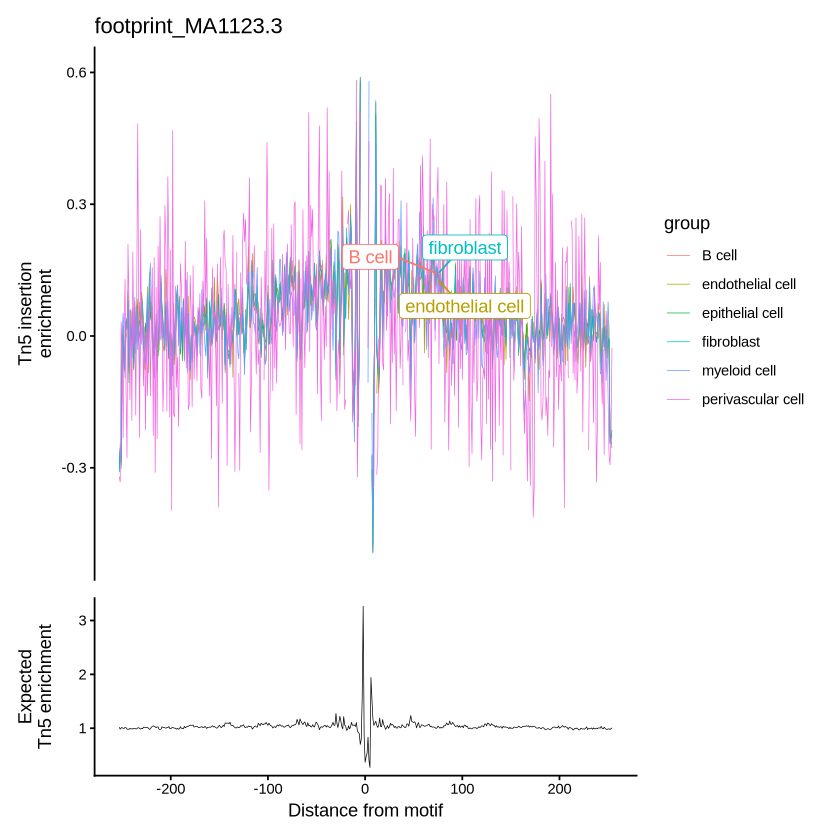

In [198]:
plot_footprint_for_motif(
  motif_name = 'MA1123.3',
  M=M, # eg adata_map.X.csv
  spot_obj=spot_obj,
  object_dissociated = object,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out_healthy.rds",
  spot_obj_out_path = "spot_obj_out_healthy.rds",
  plot_out_path = "test_healthy_MA1123.3.pdf",
  overwrite = TRUE
) 

In [203]:
motifs[2:3]

[1] "MA0698.2" "MA1638.2"

In [209]:

if (length(motifs) == 0) stop("No motifs selected for footprinting.")

print(paste0("Footprinting motifs (n=", length(motifs[2:3]), "): ", paste(motifs[2:3], collapse = ", ")))

# --- Run footprints and plot ---
for (motif in motifs[2:3]) {
    print(paste("motif:", motif))
    plot_out_path <- file.path(outdir, paste0("footprint_", motif, ".pdf"))
    res <- plot_footprint_for_motif(
        motif_name = motif,
        M = M,
        spot_obj = spot_obj,
        object_dissociated = object,
        assay = "peaks",
        clustering_var = "cell_type",
        plot_out_path = plot_out_path,
        object_dissociated_out_path = "dissociated_obj_out_healthy.rds",
        spot_obj_out_path = "spot_obj_out_healthy.rds",
        overwrite = TRUE
    )
    object <- res$object_dissociated
    spot_obj <- res$spot_obj
}

[1] "Footprinting motifs (n=2): MA0698.2, MA1638.2"


[1] "motif: MA0698.2"
[1] "class of peaks assay in original object:"
[1] "ChromatinAssay"
attr(,"package")
[1] "Signac"


Computing Tn5 insertion bias

Extracting reads in requested region

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Removed 3066 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


[1] "motif: MA1638.2"
[1] "class of peaks assay in original object:"
[1] "ChromatinAssay"
attr(,"package")
[1] "Signac"


Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Removed 3036 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


In [210]:


saveRDS(spot_obj, file.path(outdir, "spot_obj_footprints.rds"))
saveRDS(object, file.path(outdir, "dissociated_obj_footprints.rds"))

## other upload folder

"Rscript", "../backend/calc_multiome_scores/calc_multiome_scores_test.R",
"--outdir", /workspaces/swarm/frontend/../backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/junkDNA420,
"--log", /workspaces/swarm/frontend/../backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/junkDNA420/calc_scores.log + 
['--multiome_rds', '/workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/healthy_breast_preprocessed_RNA_peaks_only.rds', 
'--fragments_tsv_gz', '/workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/fake_fragments.tsv.gz', 
'--fragments_tsv_gz_tbi', '/workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/fake_fragments.tsv.gz.tbi', 
'--multiome', 
'--chromvar', 
'--footprinting', 
'--genome', 'hg38', 
'--differential_motif_activity']"

Rscript ../backend/calc_multiome_scores/calc_multiome_scores_test.R \
  --outdir /workspaces/swarm/frontend/../backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/junkDNA420 \
  --log /workspaces/swarm/frontend/../backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/junkDNA420/calc_scores.log \
  --multiome_rds /workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/healthy_breast_preprocessed_RNA_peaks_only.rds \
  --fragments_tsv_gz /workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/fake_fragments.tsv.gz \
  --fragments_tsv_gz_tbi /workspaces/swarm/backend/uploads/job_1772522034669_4c34f5e6-7455-4cd4-9f74-e52983253c33/fake_fragments.tsv.gz.tbi \
  --multiome \
  --chromvar \
  --footprinting \
  --genome hg38 \
  --differential_motif_activity